In [18]:

from pathlib import Path
import json
import pandas as pd
import re

import matplotlib.pyplot as plt
import seaborn as sns
REPO_ROOT = Path().resolve()

RESULTS_DIR = REPO_ROOT / "results"

In [19]:
# Load csv file 
output_csv = RESULTS_DIR / "aggregated_battery_results.csv"
df_all = pd.read_csv(output_csv)


# display all columns option
pd.set_option("display.max_columns", None)


# filter out runs whose path contains test1, since test2 is with varying threshold
df = df_all[df_all["path"].str.contains("cfg_test1")]


# display all rows option
pd.set_option("display.max_rows", 5)
display(df.sort_values(by=["scenario_id", "infeasibility_mode", "batch_size","final_global_error", "parallelism","RB_max_consecutive","batch_size"]))


,run_id,scenario_id,requests_in,batch_size,infeasibility_mode,parallelism,solver_time_ms_avg,elapsed_seconds,carbon_cost,carbon_saving,req_assigned_with_GF,total_RBs,peak_consecutive_RBs,RB_max_consecutive,peak_concurrent_workers,avg_concurrent_workers,online_swarm_mode,baseline_carbon_cost,final_global_error,avg_global_error_per_slot,path
45,cfg,high_load_1500_92,107064,1,carryover,1,4.91,655.40,66870.19,68.77,98,0,0,0,1,1.00,merge,214108.17,4.00,4.00,cfg_test1_dp_0_0819_1138_1_roll0_0_F_M/high_lo...
5,cfg,high_load_1500_92,107064,1,carryover,8,15.08,496.70,69874.95,67.36,1453,0,0,0,8,5.77,merge,214108.17,4.00,4.00,cfg_test1_dp_0_0816_2106_8_roll0_0_F_M/high_lo...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,cfg,xhigh_load_2000_120,144963,1,online_greedy_singleton,8,20.56,959.46,126398.30,64.96,0,131,1,8,8,6.10,merge,360701.75,3.98,3.98,cfg_test1_greedy_singleton_4_0819_0100_8_roll8...
247,cfg,xhigh_load_2000_120,144963,1,online_greedy_singleton,8,20.48,1016.04,123384.27,65.79,0,109,1,4,8,5.92,merge,360701.75,3.99,3.98,cfg_test1_greedy_singleton_2_0819_0008_8_roll4...


## Visualization for some fields
```
"carbon_saving","solver_time_ms_avg","elapsed_seconds"
```

We must visualize but separating on infeasibility_modes

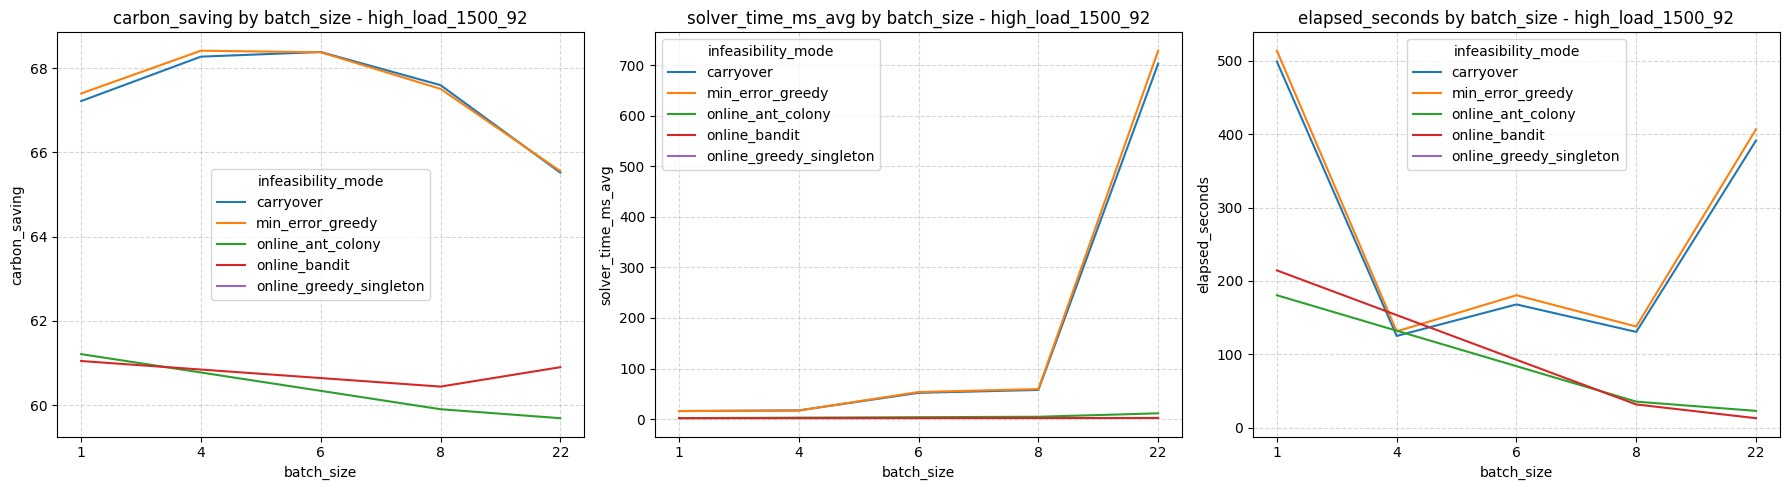

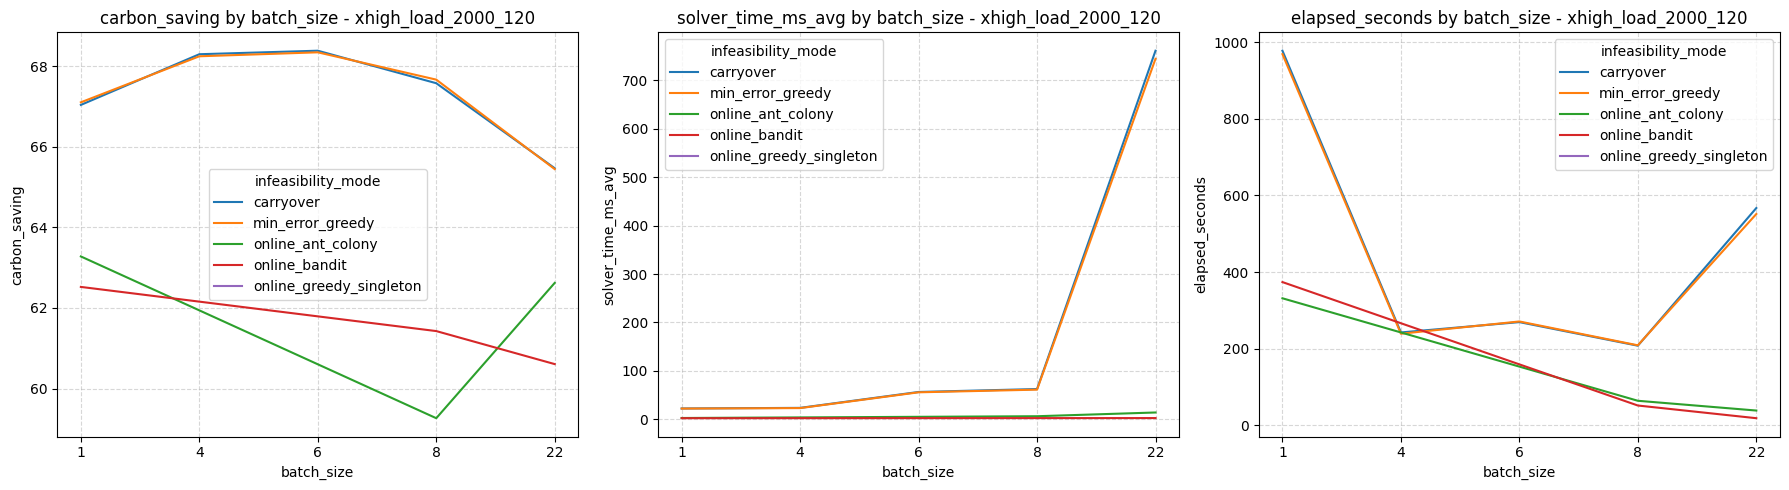

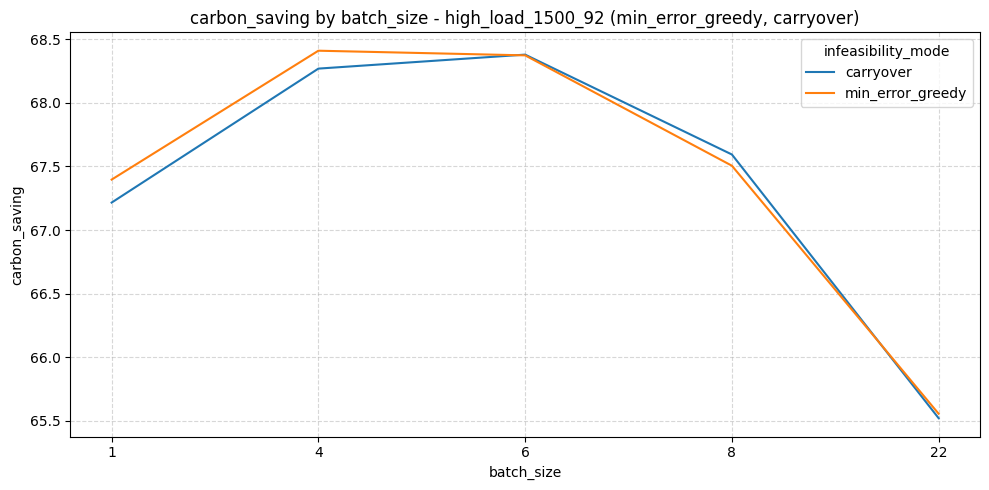

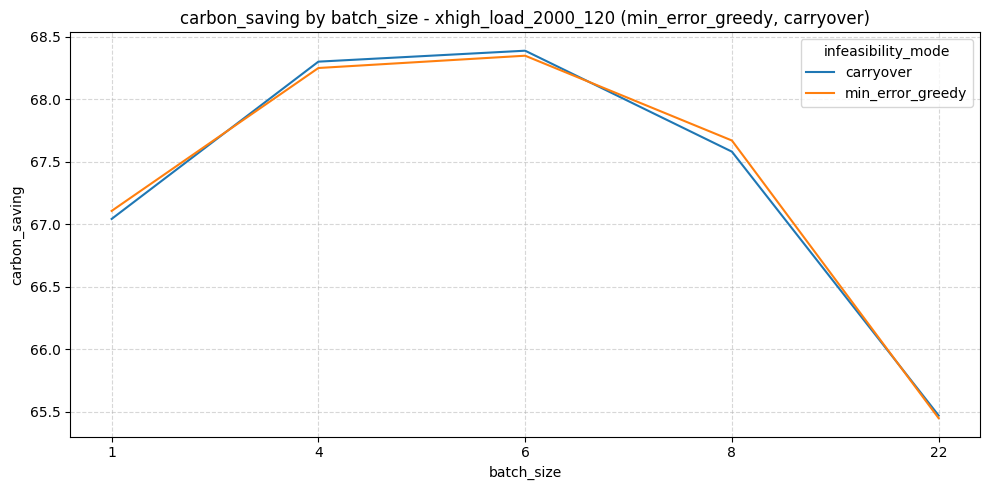

In [20]:
'''
We want to analyze these fields "carbon_saving","solver_time_ms_avg","elapsed_seconds"
We must visualize but separating on infeasibility_modes
The X axis will be the batch_size and the Y axis will be the value of the field we are analyzing.

Given that there are multiple runs, we will use the average value of the field for each batch_size and infeasibility_mode.
'''

# Work on a clean dataframe
plot_df = df.copy()
plot_df["batch_size"] = pd.to_numeric(plot_df["batch_size"], errors="coerce")
plot_df = plot_df.dropna(subset=["batch_size", "infeasibility_mode"]).copy()

# 3 subplots in a single figure: one per metric, keeping scenarios separate
metrics = ["carbon_saving", "solver_time_ms_avg", "elapsed_seconds"]

for scenario_id in sorted(plot_df["scenario_id"].unique()):
    scenario_df = plot_df[plot_df["scenario_id"] == scenario_id].copy()
    fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5))
    if len(metrics) == 1:
        axes = [axes]

    x_order = sorted(scenario_df["batch_size"].dropna().unique().tolist())
    x_map = {v: i for i, v in enumerate(x_order)}

    for ax, metric in zip(axes, metrics):
        grouped = (
            scenario_df.groupby(["batch_size", "infeasibility_mode"], as_index=False)[metric]
            .mean()
            .sort_values(["infeasibility_mode", "batch_size"])
        ).copy()
        grouped["x_pos"] = grouped["batch_size"].map(x_map)

        sns.lineplot(
            data=grouped,
            x="x_pos",
            y=metric,
            hue="infeasibility_mode",
            markers=True,
            dashes=True,
            errorbar=None,
            ax=ax,
            sort=False,
        )
        ax.set_title(f"{metric} by batch_size - {scenario_id}")
        ax.set_xlabel("batch_size")
        ax.set_ylabel(metric)
        ax.set_xticks(range(len(x_order)))
        ax.set_xticklabels([str(v) for v in x_order])
        ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

# Separate plot for carbon_saving limited to min_error_greedy and carryover, one figure per scenario
special_modes = ["min_error_greedy", "carryover"]

for scenario_id in sorted(plot_df["scenario_id"].unique()):
    special_df = plot_df[
        (plot_df["scenario_id"] == scenario_id) &
        (plot_df["infeasibility_mode"].isin(special_modes))
    ].copy()

    x_order = sorted(special_df["batch_size"].dropna().unique().tolist())
    x_map = {v: i for i, v in enumerate(x_order)}
    grouped = (
        special_df.groupby(["batch_size", "infeasibility_mode"], as_index=False)["carbon_saving"]
        .mean()
        .sort_values(["infeasibility_mode", "batch_size"])
    ).copy()
    grouped["x_pos"] = grouped["batch_size"].map(x_map)

    plt.figure(figsize=(10, 5))
    sns.lineplot(
        data=grouped,
        x="x_pos",
        y="carbon_saving",
        hue="infeasibility_mode",
        markers=True,
        dashes=True,
        errorbar=None,
        sort=False,
    )
    plt.title(f"carbon_saving by batch_size - {scenario_id} ({', '.join(special_modes)})")
    plt.xlabel("batch_size")
    plt.ylabel("carbon_saving")
    plt.xticks(range(len(x_order)), [str(v) for v in x_order])
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


,scenario_id,infeasibility_mode,batch_size,carbon_saving_avg,carbon_saving_min,carbon_saving_max,elapsed_seconds_avg,elapsed_seconds_min,elapsed_seconds_max
0,high_load_1500_92,carryover,4,68.270000,67.90,69.32,125.050833,104.45,204.88
1,high_load_1500_92,carryover,6,68.380000,67.91,69.38,168.031667,133.54,473.20
2,high_load_1500_92,carryover,8,67.594167,66.67,69.81,130.556667,101.84,379.14
3,high_load_1500_92,min_error_greedy,4,68.410833,68.08,69.35,131.288333,106.99,239.44
4,high_load_1500_92,min_error_greedy,6,68.374167,67.79,69.66,180.546667,131.14,570.99
5,high_load_1500_92,min_error_greedy,8,67.505833,66.42,69.80,137.930833,98.60,426.26
6,xhigh_load_2000_120,carryover,4,68.300833,67.93,69.40,242.566667,215.84,384.21
7,xhigh_load_2000_120,carryover,6,68.388333,68.01,69.96,269.560833,218.97,656.50
8,xhigh_load_2000_120,carryover,8,67.580833,66.90,70.12,207.990833,166.76,531.29
9,xhigh_load_2000_120,min_error_greedy,4,68.250000,67.85,69.65,239.234167,201.61,370.95


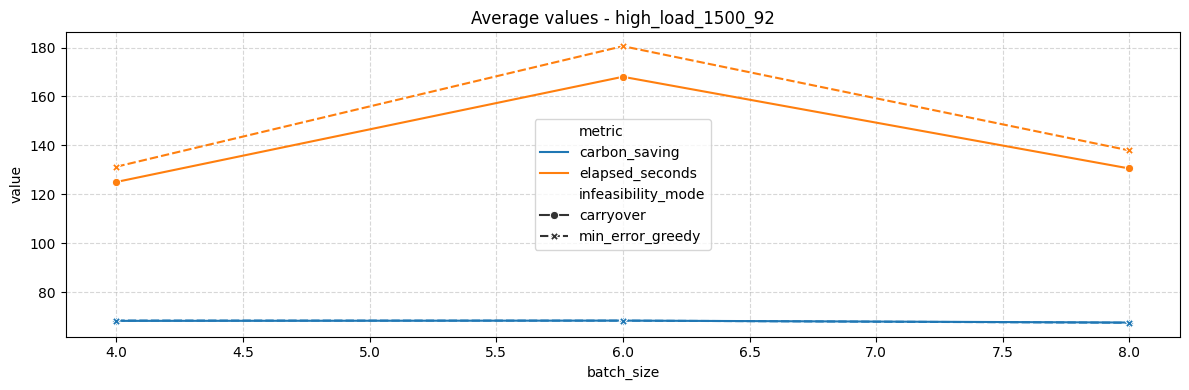

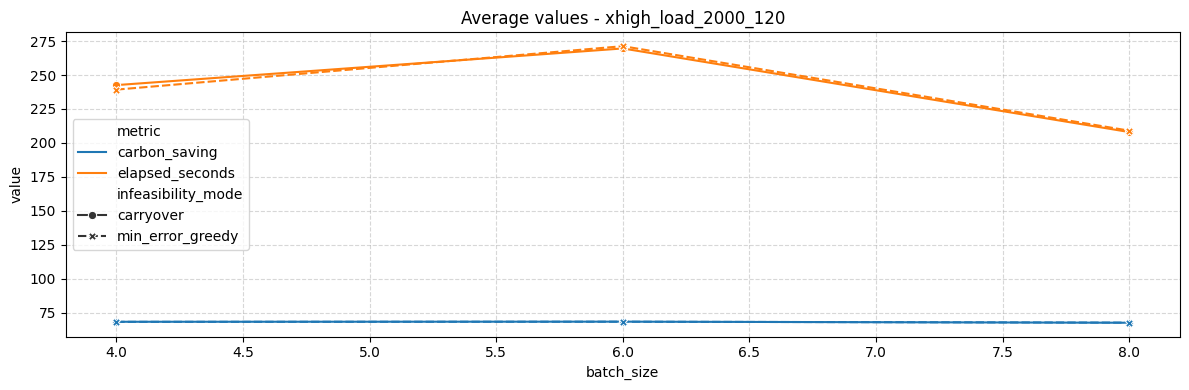

In [21]:
'''
Let's narrow this down a little bit
Get average, min, max values for carbon_saving and elapsed_seconds
with batch_size in [4,6,8] and infeasibility_mode in ["min_error_greedy", "carryover"]
'''

filtered = plot_df[
    (plot_df["batch_size"].isin([4, 6, 8])) &
    (plot_df["infeasibility_mode"].isin(["min_error_greedy", "carryover"]))
].copy()

summary = (
    filtered.groupby(["scenario_id", "infeasibility_mode", "batch_size"], as_index=False)
    .agg(
        carbon_saving_avg=("carbon_saving", "mean"),
        carbon_saving_min=("carbon_saving", "min"),
        carbon_saving_max=("carbon_saving", "max"),
        elapsed_seconds_avg=("elapsed_seconds", "mean"),
        elapsed_seconds_min=("elapsed_seconds", "min"),
        elapsed_seconds_max=("elapsed_seconds", "max"),
    )
    .sort_values(["scenario_id", "infeasibility_mode", "batch_size"])
    .reset_index(drop=True)
)
pd.set_option("display.max_rows", None)
display(summary)

# Compact plot per scenario: average values for carbon_saving and elapsed_seconds
for scenario_id in sorted(filtered["scenario_id"].unique()):
    subset = summary[summary["scenario_id"] == scenario_id].copy()
    subset_long = subset.melt(
        id_vars=["scenario_id", "infeasibility_mode", "batch_size"],
        value_vars=[
            "carbon_saving_avg",
            "elapsed_seconds_avg",
        ],
        var_name="metric",
        value_name="value",
    )
    subset_long["metric"] = subset_long["metric"].str.replace("_avg", "", regex=False)

    plt.figure(figsize=(12, 4))
    sns.lineplot(
        data=subset_long,
        x="batch_size",
        y="value",
        hue="metric",
        style="infeasibility_mode",
        markers=True,
        dashes=True,
        errorbar=None,
    )
    plt.title(f"Average values - {scenario_id}")
    plt.xlabel("batch_size")
    plt.ylabel("value")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

## Parallelism and rollback

In [22]:
# Let's understand if more parallelism yields less elapsed_time
# Get only carryover and min_error_greedy modes
df_gr_ret = df[~df["infeasibility_mode"].str.contains("offline|online")]
# For each scenario and for each N, we want to know a much elapsed_time is spared with runs having parallelism > 1 compared to runs with parallelism = 1
group_cols = ["scenario_id", "batch_size"]

# Baseline: prendiamo il max elapsed_seconds tra le run con parallelism=1
baseline = (
    df_gr_ret[df_gr_ret["parallelism"] == 1]
    .groupby(group_cols)
    .agg(
        elapsed_parallelism_1=("elapsed_seconds", "max"),
    )
    .reset_index()
)

# Run con parallelism > 1
parallel = (
    df_gr_ret[df_gr_ret["parallelism"] > 1]
    [
        group_cols
        + [
            "parallelism",
            "elapsed_seconds",
            "peak_concurrent_workers",
            "avg_concurrent_workers",
            "infeasibility_mode",
            "RB_max_consecutive",
            "total_RBs",
            "carbon_saving"
        ]
    ]
)

# confronto
comparison = parallel.merge(
    baseline,
    on=group_cols,
    how="inner",
)

comparison["seconds_saved"] = (
    comparison["elapsed_parallelism_1"]
    - comparison["elapsed_seconds"]
)

comparison["speedup_pct"] = (
    comparison["seconds_saved"]
    / comparison["elapsed_parallelism_1"]
    * 100
)

# Set columns ordering for comparison for better readability
comparison = comparison[
    [
        "scenario_id",
        "batch_size",
        "parallelism",
        "elapsed_seconds",
        "elapsed_parallelism_1",
        "seconds_saved",
        "speedup_pct",
        "carbon_saving",
        "peak_concurrent_workers",
        "avg_concurrent_workers",
        "infeasibility_mode",
        "RB_max_consecutive",
        "total_RBs",
    ]
] 

display(comparison.head())
# comparison
# display for scenario xxhigh_load_2081
# display(comparison[(comparison["scenario_id"] == "xxhigh_load_2081") & (comparison["batch_size"] == 16)])
# display(comparison[(comparison["scenario_id"] == "high_load_105") & (comparison["batch_size"] == 16)])
# display(comparison[(comparison["scenario_id"] == "low_load_2028") & (comparison["batch_size"] == 16)])


summary = (
    comparison
    .groupby("parallelism")
    .agg(
        runs=("scenario_id", "count"),
        avg_saved_seconds=("seconds_saved", "mean"),
        median_saved_seconds=("seconds_saved", "median"),
        avg_speedup_pct=("speedup_pct", "mean"),
        median_speedup_pct=("speedup_pct", "median"),
        avg_peak_workers=("peak_concurrent_workers", "mean"),
        avg_workers=("avg_concurrent_workers", "mean"),
        avg_rollbacks=("total_RBs", "mean"),
    )
)

summary

,scenario_id,batch_size,parallelism,elapsed_seconds,elapsed_parallelism_1,seconds_saved,speedup_pct,carbon_saving,peak_concurrent_workers,avg_concurrent_workers,infeasibility_mode,RB_max_consecutive,total_RBs
0,high_load_1500_92,1,8,458.72,709.98,251.26,35.389729,67.37,8,5.81,min_error_greedy,0,0
1,high_load_1500_92,4,8,108.75,239.44,130.69,54.581524,68.31,8,6.47,min_error_greedy,0,0
2,high_load_1500_92,6,8,136.85,570.99,434.14,76.032855,68.50,8,7.29,min_error_greedy,0,0
3,high_load_1500_92,8,8,102.98,426.26,323.28,75.841036,67.65,8,7.49,min_error_greedy,0,0
4,high_load_1500_92,22,8,361.82,1184.11,822.29,69.443717,65.14,8,7.56,min_error_greedy,0,0


,runs,avg_saved_seconds,median_saved_seconds,avg_speedup_pct,median_speedup_pct,avg_peak_workers,avg_workers,avg_rollbacks
parallelism,,,,,,,,
8,100,454.4092,393.515,58.316248,67.833715,8.0,6.8920,194.68
14,20,462.5520,386.270,59.097333,67.341951,14.0,10.0160,0.00
20,100,451.9849,379.660,57.296773,67.276705,20.0,11.3463,351.57


### Parallelismo useful
Parallelism yields a significant reduction in elapsed_time. Speedup peaks at 75% for N=6|8, and yields a 54% reduction for N=4. The speedup is less pronounced for N=1, but still yields a 35% reduction in elapsed_time.

`avg_workers` stays at 11 even for `parallelism=20` probably due to my **hardware capabilities**, despite having set a higher number of thread dedicated to WSL.

## Rollback evaluation

Top 5 runs for xhigh_load_2000_120 by carbon_saving:


,batch_size,parallelism,infeasibility_mode,carbon_saving,elapsed_seconds,total_RBs
53,8,1,min_error_greedy,70.15,577.20,0
58,8,1,carryover,70.12,531.29,0
57,6,1,carryover,69.96,656.50,0
52,6,1,min_error_greedy,69.85,697.41,0
51,4,1,min_error_greedy,69.65,370.95,0


Top 5 runs with total_RBs > 0: 0 / 5


,group,runs,avg_carbon_saving,avg_elapsed_seconds,min_carbon_saving,max_carbon_saving
0,with_rollbacks,44,67.025227,482.965,63.19,68.60
1,without_rollbacks,100,66.290500,412.518,55.79,70.15


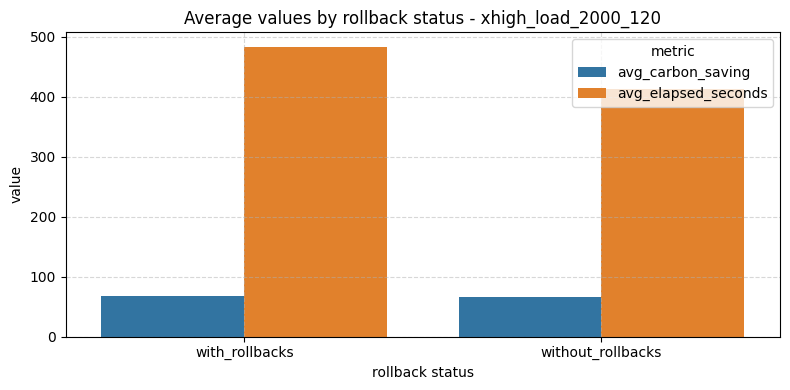

In [23]:
'''
Get the top 5 runs for carbon saving for one scenario. Check how many of them have total_RBs > 0.
Then get the runs with total_RBs > 0 and measure the average carbon saving and elapsed_time for them.
Compare with the average carbon saving and elapsed_time for runs with no rollbacks.
'''

# Pick one scenario to analyze
# scenario = "high_load_1500_92"
scenario = "xhigh_load_2000_120"

scenario_df = df[df["scenario_id"] == scenario].copy()

# Keep only meaningful columns for the analysis
cols = [
    "scenario_id",
    "batch_size",
    "parallelism",
    "infeasibility_mode",
    "carbon_saving",
    "elapsed_seconds",
    "total_RBs",
    "RB_max_consecutive",
    "final_global_error",
]
scenario_df = scenario_df[cols].copy()

# Top 5 runs by carbon saving
top5 = scenario_df.nlargest(5, "carbon_saving").copy()
# For better readability, display the exact top 5 rows
print(f"Top 5 runs for {scenario} by carbon_saving:")
display(top5[["batch_size", "parallelism", "infeasibility_mode", "carbon_saving", "elapsed_seconds", "total_RBs"]])

# Check how many of the top 5 have total_RBs > 0
num_with_rollbacks = int((top5["total_RBs"] > 0).sum())
print(f"Top 5 runs with total_RBs > 0: {num_with_rollbacks} / 5")

# Compare averages for runs with and without rollbacks
with_rollbacks = scenario_df[scenario_df["total_RBs"] > 0].copy()
without_rollbacks = scenario_df[scenario_df["total_RBs"] == 0].copy()

summary = {
    "group": ["with_rollbacks", "without_rollbacks"],
    "runs": [
        len(with_rollbacks),
        len(without_rollbacks),
    ],
    "avg_carbon_saving": [
        with_rollbacks["carbon_saving"].mean() if len(with_rollbacks) else None,
        without_rollbacks["carbon_saving"].mean() if len(without_rollbacks) else None,
    ],
    "avg_elapsed_seconds": [
        with_rollbacks["elapsed_seconds"].mean() if len(with_rollbacks) else None,
        without_rollbacks["elapsed_seconds"].mean() if len(without_rollbacks) else None,
    ],
    "min_carbon_saving": [
        with_rollbacks["carbon_saving"].min() if len(with_rollbacks) else None,
        without_rollbacks["carbon_saving"].min() if len(without_rollbacks) else None,
    ],
    "max_carbon_saving": [
        with_rollbacks["carbon_saving"].max() if len(with_rollbacks) else None,
        without_rollbacks["carbon_saving"].max() if len(without_rollbacks) else None,
    ],
}

summary_df = pd.DataFrame(summary)
display(summary_df)

# Optional plot: compare mean carbon_saving and elapsed_seconds for groups
summary_plot = summary_df[["group", "avg_carbon_saving", "avg_elapsed_seconds"]].copy()
summary_plot = summary_plot.melt(
    id_vars="group",
    value_vars=["avg_carbon_saving", "avg_elapsed_seconds"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(8, 4))
sns.barplot(data=summary_plot, x="group", y="value", hue="metric")
plt.title(f"Average values by rollback status - {scenario}")
plt.ylabel("value")
plt.xlabel("rollback status")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Rollback not so useful
Rollbacks ensure a higher minimum carbon saving (63% vs 56%), but the average carbon saving is almost the same (75% vs 80%). The elapsed_time instead is higher, 1.16x times slower for runs with rollbacks than for runs without rollbacks (482s vs 412s for high_load_1900_92).

Rollbacks can probably be avoided.



## Planet vs Profit
`test2` marked tests have the error threshold varying in `(3.0,3.5,4.0,4.5)` to observe how much the error threshold affects the carbon saving. The results show that the error threshold has a significant impact on the carbon saving, with higher thresholds yielding lower carbon savings.

In fact, the intuition is that simply relying on time shifting does not yield much carbon saving (if any), and that the main source of carbon saving is exploiting the error threshold.

/tmp/ipykernel_483327/3043629992.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scenario_df


,infeasibility_mode,error_threshold_bin,avg_carbon_saving
0,carryover,3.0,51.396000
1,offline_ant_colony,3.0,54.640000
2,offline_bandit,3.0,45.210000
3,offline_greedy_cheapest,3.0,54.810000
4,online_ant_colony,3.0,38.340000
5,online_bandit,3.0,41.453333
6,online_greedy_singleton,3.0,42.830000
7,carryover,3.5,59.356000
8,offline_ant_colony,3.5,61.750000
9,offline_bandit,3.5,51.720000


infeasibility_mode,carryover,offline_ant_colony,offline_bandit,offline_greedy_cheapest,online_ant_colony,online_bandit,online_greedy_singleton
error_threshold_bin,,,,,,,
3.0,51.396,54.64,45.21,54.81,38.340000,41.453333,42.83
3.5,59.356,61.75,51.72,61.74,50.070000,49.133333,53.42
4.0,67.528,69.94,62.24,68.55,61.364444,60.494444,66.35
4.5,75.394,77.04,69.68,75.61,71.123333,68.850000,75.39


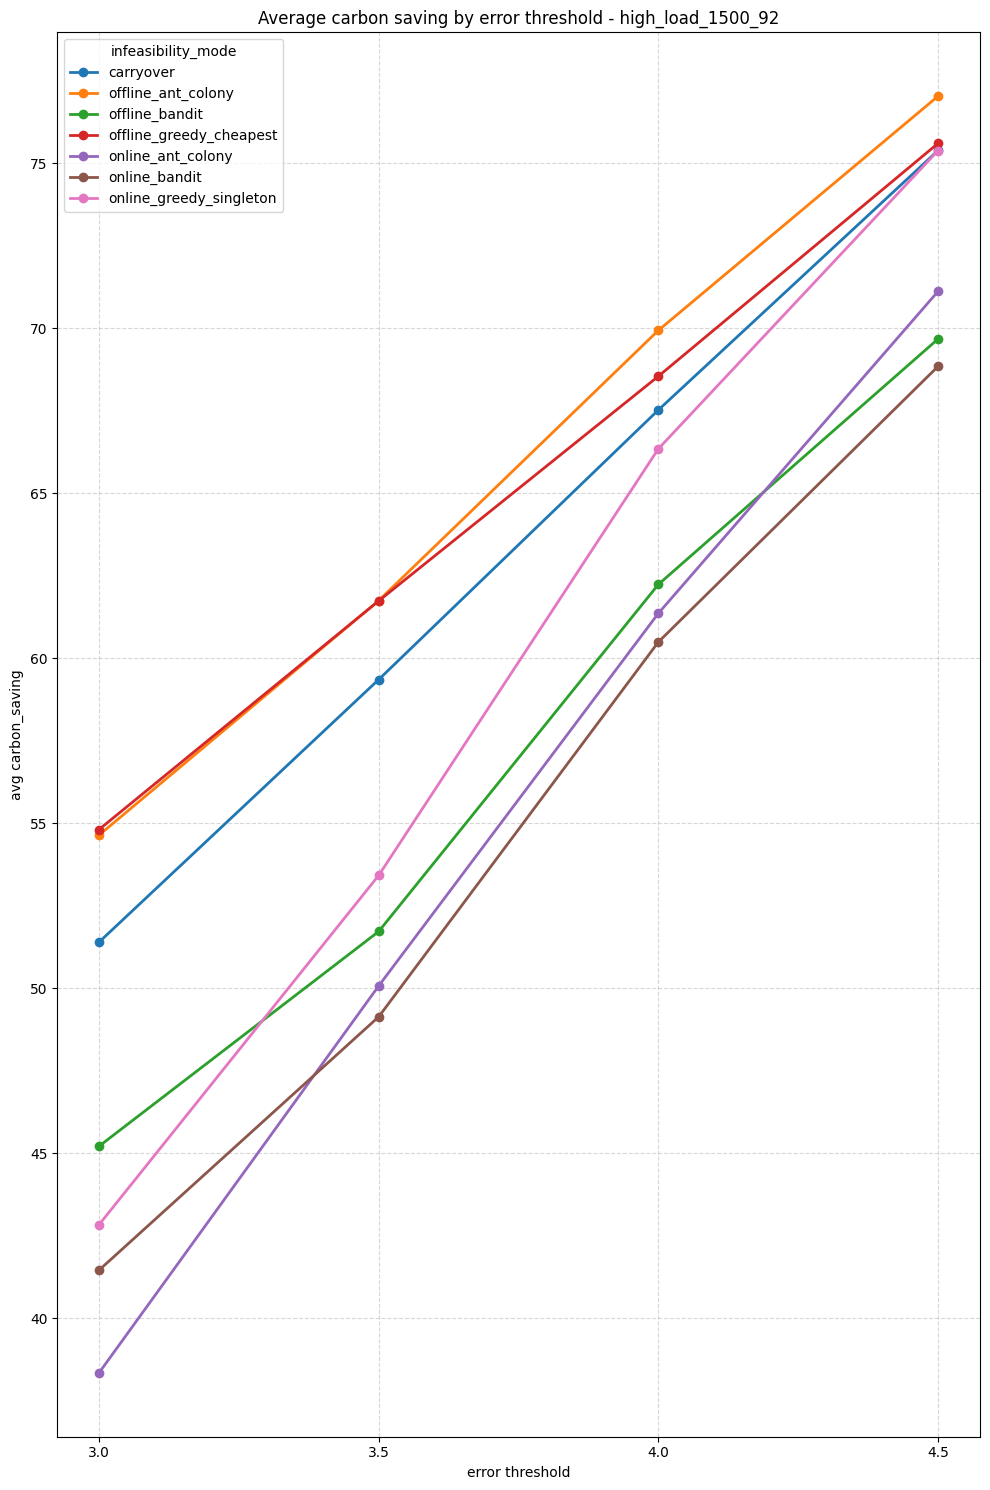

In [24]:
'''
Display average carbon saving for each infeasibility_mode for each error threshold for a selected scenario.
Consider that final_global_error should be close to the error threshold used, but may differ of a few percents (e.g. if the threshold is 4.0, final_global_err may be 3.98).
It would be wise to use binning, knowing that the error threshold is in (3.0, 3.5, 4.0, 4.5).
'''

df_2 = df_all[df_all["path"].str.contains("cfg_test2")].copy()

# Pick a scenario to analyze
scenario = "high_load_1500_92"
# scenario = "xhigh_load_2000_120"

scenario_df = df_2[df_2["scenario_id"] == scenario].copy()
scenario_df["final_global_error"] = pd.to_numeric(scenario_df["final_global_error"], errors="coerce")
scenario_df = scenario_df.dropna(subset=["final_global_error", "carbon_saving", "infeasibility_mode"]).copy()

# Error thresholds used in the experiment
thresholds = [3.0, 3.5, 4.0, 4.5]
# Use a small bin around each threshold to account for small numerical differences
bins = [2.75, 3.25, 3.75, 4.25, 4.75]
labels = [3.0, 3.5, 4.0, 4.5]

scenario_df["error_threshold_bin"] = pd.cut(
    scenario_df["final_global_error"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False,
)

summary = (
    scenario_df
    .dropna(subset=["error_threshold_bin"])
    .groupby(["infeasibility_mode", "error_threshold_bin"], as_index=False)["carbon_saving"]
    .mean()
    .rename(columns={"carbon_saving": "avg_carbon_saving"})
    .sort_values(["error_threshold_bin", "infeasibility_mode"])
    .reset_index(drop=True)
)

display(summary)

# Pivot table for easier comparison
pivot = (
    summary
    .pivot(index="error_threshold_bin", columns="infeasibility_mode", values="avg_carbon_saving")
    .reindex(labels)
)
display(pivot)

# Plot: average carbon saving by error threshold, one line per infeasibility mode
plt.figure(figsize=(10, 15))
for mode in pivot.columns:
    plt.plot(pivot.index.astype(float), pivot[mode].values, marker="o", linewidth=2, label=mode)

plt.title(f"Average carbon saving by error threshold - {scenario}")
plt.xlabel("error threshold")
plt.ylabel("avg carbon_saving")
plt.xticks(thresholds)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="infeasibility_mode")
plt.tight_layout()
plt.show()

## Relying only on shifting

So, to prove the intuition mentioned above, let's limit the **flavours** to only the most accurate one, making the time shift the only possible source of carbon saving.


What is expected is that if the sinusoidal load is in phase with the carbon intensity, then the carbon saving should be significant, while if it is opposed in phase, then the carbon saving should be negligible.

`test3` have phase opposition, `test4` are in phase, `test5` have phase 0.25% disalignment.
TODO check

In [25]:
df_shift = df_all[df_all["path"].str.contains("cfg_test3") |
     df_all["path"].str.contains("cfg_test4") |
     df_all["path"].str.contains("cfg_test5")].copy()

df_test3 = df_all[df_all["path"].str.contains("cfg_test3")].copy()
df_test4 = df_all[df_all["path"].str.contains("cfg_test4")].copy()
df_test5 = df_all[df_all["path"].str.contains("cfg_test5")].copy()

display(df_test3.head())
display(df_test4.head())
display(df_test5.head())




,run_id,scenario_id,requests_in,batch_size,infeasibility_mode,parallelism,solver_time_ms_avg,elapsed_seconds,carbon_cost,carbon_saving,req_assigned_with_GF,total_RBs,peak_consecutive_RBs,RB_max_consecutive,peak_concurrent_workers,avg_concurrent_workers,online_swarm_mode,baseline_carbon_cost,final_global_error,avg_global_error_per_slot,path
432,cfg,high_load_1500_92,107064,4,carryover,12,15.41,112.43,223375.71,-4.33,0,0,0,0,12,7.27,merge,214108.17,0.0,0.0,cfg_test3_dp_0_0821_2109_12_roll0_0_F_M/high_l...
433,cfg,xhigh_load_2000_120,144963,4,carryover,12,22.80,217.79,379487.32,-5.21,0,0,0,0,12,7.45,merge,360701.75,0.0,0.0,cfg_test3_dp_0_0821_2109_12_roll0_0_F_M/xhigh_...
434,cfg,high_load_1500_92,107064,4,carryover,12,15.95,116.59,223300.65,-4.29,0,0,0,0,12,7.22,merge,214108.17,0.0,0.0,cfg_test3_dp_0_0821_2115_12_roll0_0_F_M/high_l...
435,cfg,xhigh_load_2000_120,144963,4,carryover,12,23.74,213.42,379331.46,-5.16,0,0,0,0,12,7.74,merge,360701.75,0.0,0.0,cfg_test3_dp_0_0821_2115_12_roll0_0_F_M/xhigh_...


,run_id,scenario_id,requests_in,batch_size,infeasibility_mode,parallelism,solver_time_ms_avg,elapsed_seconds,carbon_cost,carbon_saving,req_assigned_with_GF,total_RBs,peak_consecutive_RBs,RB_max_consecutive,peak_concurrent_workers,avg_concurrent_workers,online_swarm_mode,baseline_carbon_cost,final_global_error,avg_global_error_per_slot,path
436,cfg,high_load_1500_92,107064,4,carryover,12,15.55,104.46,431436.09,10.77,0,0,0,0,12,7.56,merge,483486.55,0.0,0.0,cfg_test4_dp_0_0821_2137_12_roll0_0_F_M/high_l...
437,cfg,xhigh_load_2000_120,144963,4,carryover,12,22.49,200.26,648450.17,21.69,0,0,0,0,12,7.77,merge,828016.04,0.0,0.0,cfg_test4_dp_0_0821_2137_12_roll0_0_F_M/xhigh_...
438,cfg,high_load_1500_92,107064,4,carryover,12,15.02,102.29,431439.93,10.76,0,0,0,0,12,7.31,merge,483486.55,0.0,0.0,cfg_test4_dp_0_0821_2148_12_roll0_0_F_M/high_l...
439,cfg,xhigh_load_2000_120,144963,4,carryover,12,22.54,206.11,648353.94,21.70,0,0,0,0,12,7.52,merge,828016.04,0.0,0.0,cfg_test4_dp_0_0821_2148_12_roll0_0_F_M/xhigh_...


,run_id,scenario_id,requests_in,batch_size,infeasibility_mode,parallelism,solver_time_ms_avg,elapsed_seconds,carbon_cost,carbon_saving,req_assigned_with_GF,total_RBs,peak_consecutive_RBs,RB_max_consecutive,peak_concurrent_workers,avg_concurrent_workers,online_swarm_mode,baseline_carbon_cost,final_global_error,avg_global_error_per_slot,path
440,cfg,high_load_1500_92,107064,4,carryover,12,14.72,101.61,420086.76,6.82,0,0,0,0,12,7.19,merge,450834.72,0.0,0.0,cfg_test5_dp_0_0821_2202_12_roll0_0_F_M/high_l...
441,cfg,xhigh_load_2000_120,144963,4,carryover,12,21.85,198.86,694767.20,8.42,0,0,0,0,12,7.76,merge,758626.06,0.0,0.0,cfg_test5_dp_0_0821_2202_12_roll0_0_F_M/xhigh_...
